## Spotify Music Clustering Project

Music streaming platforms like Spotify generate vast amounts of data related to song characteristics, user preferences, and listening habits. Understanding patterns in this data can help in tasks such as music recommendation, playlist generation, and genre discovery. In this project you are to focus on using clustering techniques to group songs based on their audio features, uncovering hidden structures in the dataset. By analyzing these clusters, one can gain insights into different music styles and potentially enhance recommendation systems.

### 1. Load necessary libraries & Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#load the dataset
data=pd.read_csv(r"D:\Advanced_Machine_Learning\Clustering_Algorithms\dataset\ML_spotify_data.csv")
data.head()

,name,artists,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo
0,We're For The Dark - Remastered 2010,['Badfinger'],22,0.678,0.559,0.432,0,3,0.0727,-12.696,0.0334,117.674
1,Sixty Years On - Piano Demo,['Elton John'],25,0.456,0.259,0.368,0,6,0.1560,-10.692,0.0280,143.783
2,Got to Find Another Way,['The Guess Who'],21,0.433,0.833,0.724,0,0,0.1700,-9.803,0.0378,84.341
3,Feelin' Alright - Live At The Fillmore East/1970,['Joe Cocker'],22,0.436,0.870,0.914,0,5,0.8550,-6.955,0.0610,174.005
4,Caravan - Take 7,['Van Morrison'],23,0.669,0.564,0.412,0,7,0.4010,-13.095,0.0679,78.716


In [3]:
#check and drop for duplicates
data[data.duplicated()]
data.drop_duplicates(inplace=True)

In [4]:
#check for missingness
data.isnull().sum()

name            0
artists         0
popularity      0
danceability    0
valence         0
energy          0
explicit        0
key             0
liveness        0
loudness        0
speechiness     0
tempo           0
dtype: int64

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9999 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          9999 non-null   object 
 1   artists       9999 non-null   object 
 2   popularity    9999 non-null   int64  
 3   danceability  9999 non-null   float64
 4   valence       9999 non-null   float64
 5   energy        9999 non-null   float64
 6   explicit      9999 non-null   int64  
 7   key           9999 non-null   int64  
 8   liveness      9999 non-null   float64
 9   loudness      9999 non-null   float64
 10  speechiness   9999 non-null   float64
 11  tempo         9999 non-null   float64
dtypes: float64(7), int64(3), object(2)
memory usage: 1015.5+ KB


### 2. Exploratory Data Analysis (EDA)

In [6]:
num_df=data.select_dtypes(include=np.number)
cat_df=data.select_dtypes(exclude=np.number)

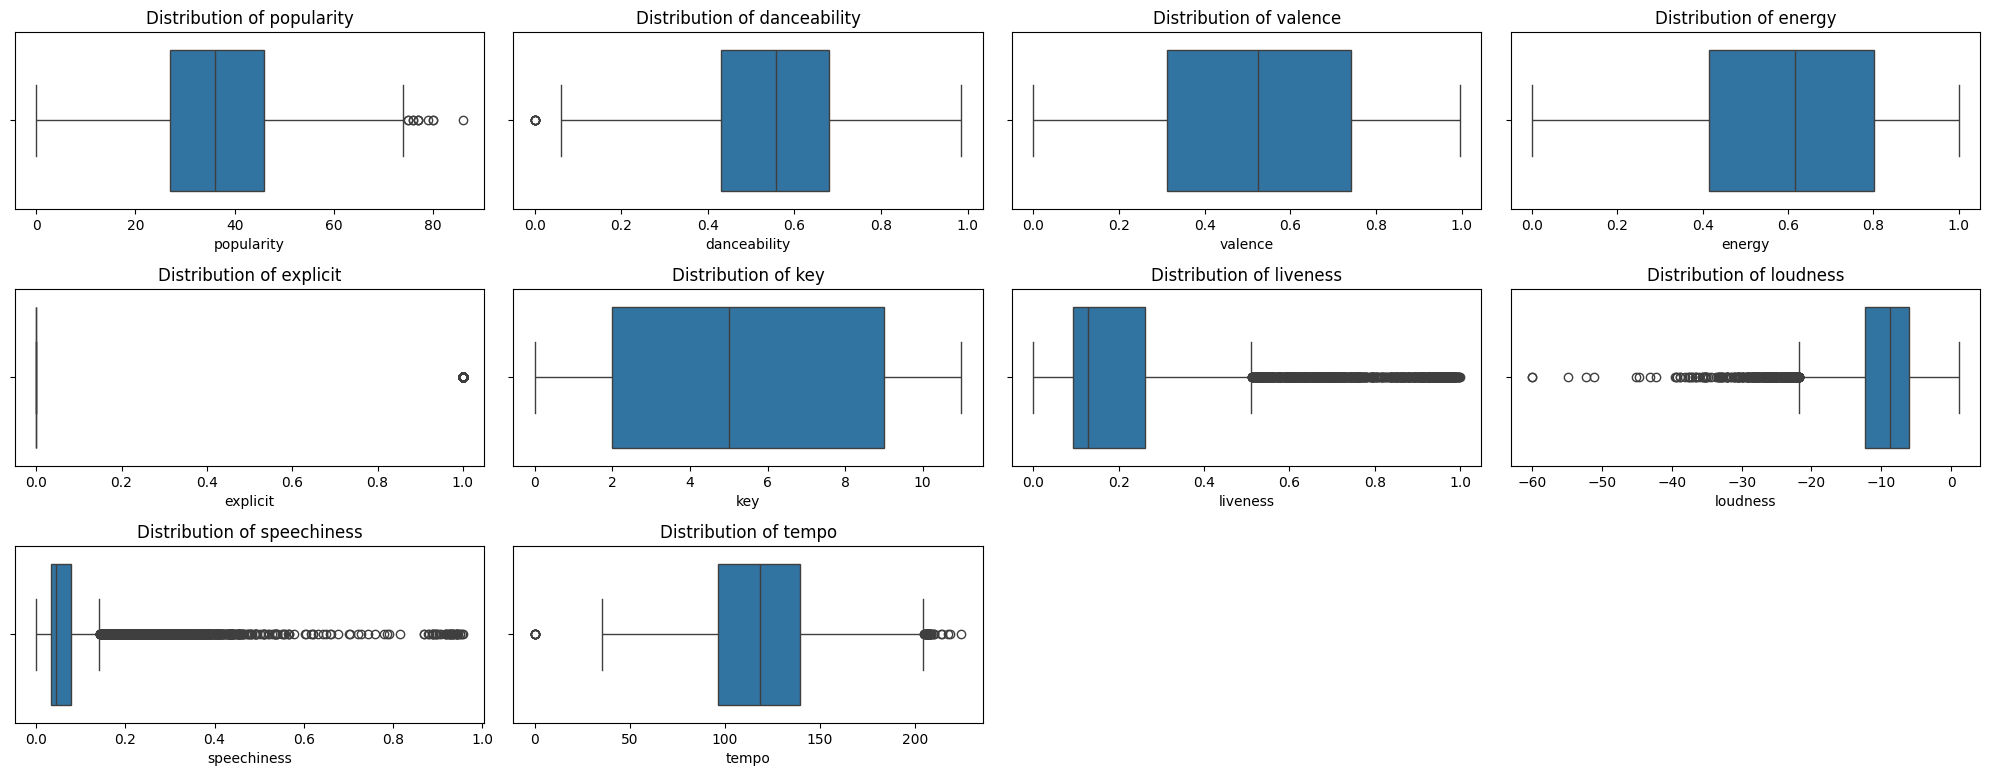

In [10]:
fig=plt.figure(figsize=(20,10))
for i in range(len(num_df.columns)):
    plt.subplot(4,4,i+1)
    sns.boxplot(x=num_df.columns[i],data=num_df)
    plt.title("Distribution of " + num_df.columns[i])
    plt.xlabel(num_df.columns[i])
plt.tight_layout()
plt.show()

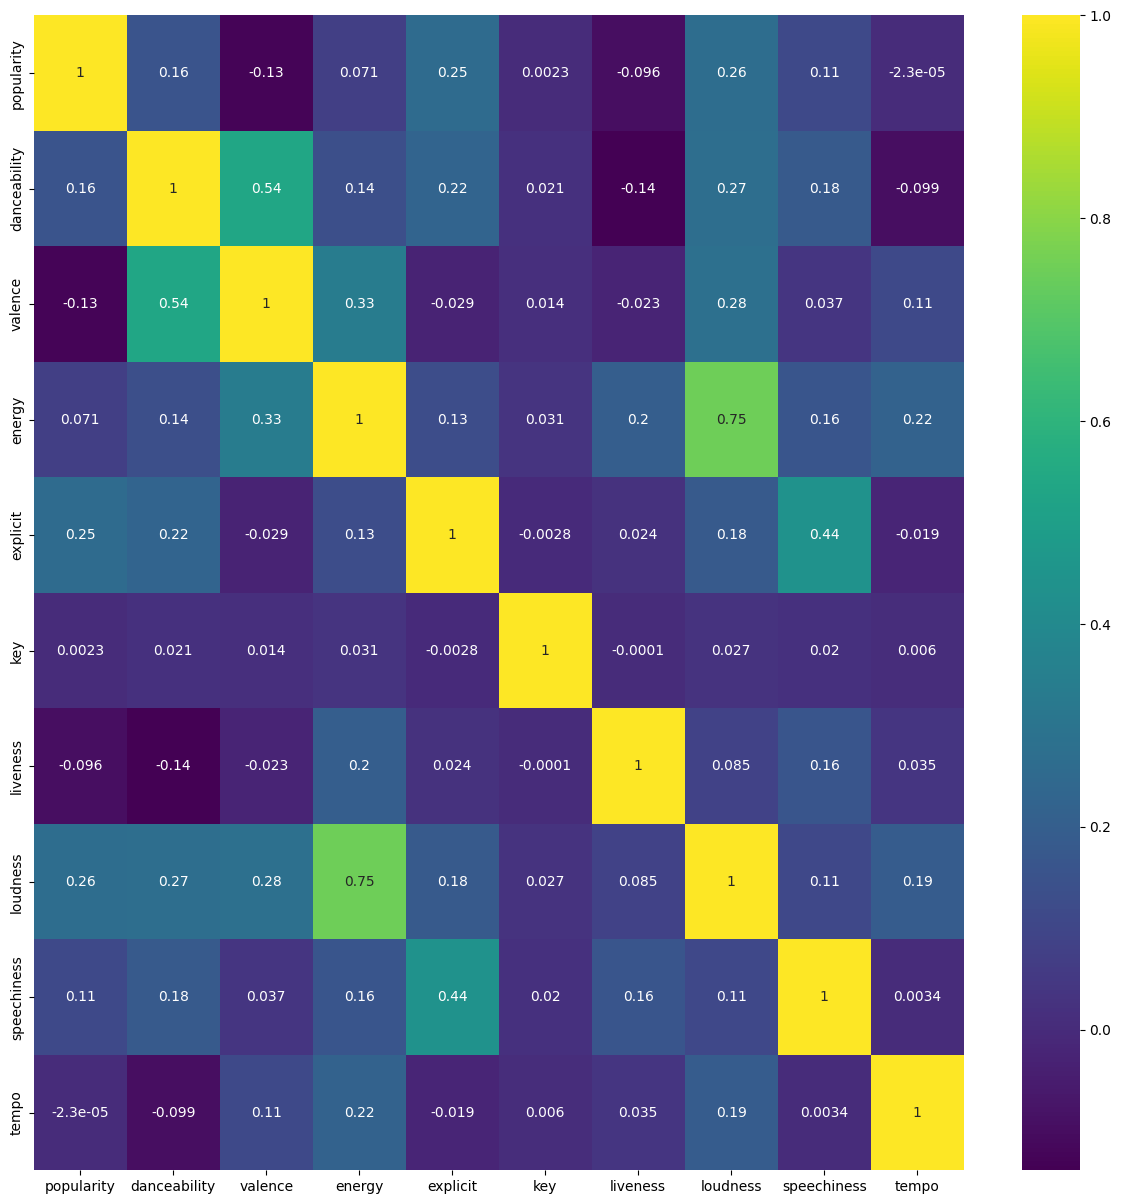

In [11]:
#correlation matrix
corrmat = num_df.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(15,15))
g=sns.heatmap(num_df[top_corr_features].corr(),annot=True,cmap="viridis")

### 3. Data pre-processsing & preparation

In [15]:
# feature scaling
from sklearn.preprocessing import StandardScaler, RobustScaler

df=num_df.copy()
scaler=RobustScaler()
scaled_df=scaler.fit_transform(df)
scaled_df=pd.DataFrame(scaled_df, columns=df.columns)

In [16]:
scaled_df.head()

,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo
0,-0.736842,0.482072,0.081585,-0.475452,0.0,-0.285714,-0.336924,-0.626792,-0.270833,-0.015062
1,-0.578947,-0.402390,-0.617716,-0.640827,0.0,0.142857,0.161580,-0.307582,-0.395833,0.586230
2,-0.789474,-0.494024,0.720280,0.279070,0.0,-0.714286,0.245362,-0.165976,-0.168981,-0.782723
3,-0.736842,-0.482072,0.806527,0.770026,0.0,0.000000,4.344704,0.287671,0.368056,1.282245
4,-0.684211,0.446215,0.093240,-0.527132,0.0,0.285714,1.627768,-0.690347,0.527778,-0.912267


### 4. Clustering Algorithms

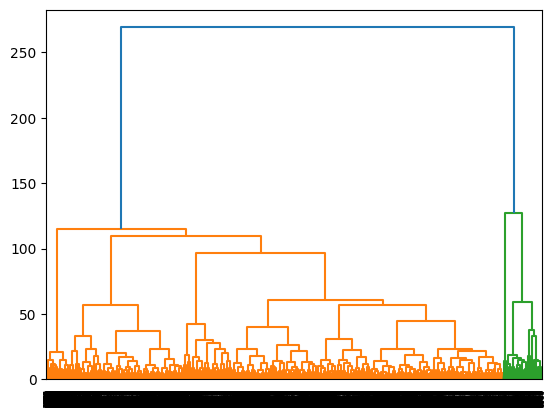

In [ ]:
#start with hierarchical clustering- just to identify the number of clusters, roughly
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

wards_clustering = linkage(scaled_df, method="ward")
dendrogram(wards_clustering)
plt.show()

NOTE: Please note, for hierarchical clustering, because I am just using it to give me an idea of a good value of clusters for my other clustering algorithms I used a simple library called scipy, please run ```pip install scipy``` on your terminal to get started with it. Why did I use it? because the library has a native way of plotting dendograms- which is what I want, so that I can see any natural groupings in my data.

In [17]:
#apply K-means clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=0,init='k-means++',n_init="auto").fit(scaled_df)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_


print(centroids)
print("\nCluster Labels for Data Points:")
print(labels)

[[ 1.35252277e-01  1.22386654e-01  1.79129026e-01  1.78650406e-01
   7.36374509e-02  3.69285592e-02  1.78734164e-01  1.50818310e-01
   2.51979042e-01  1.22962137e-01]
 [-1.33166443e-01 -3.70942679e-01 -6.54097913e-02  2.55526664e-01
   5.10440835e-02  2.90023202e-02  3.39320551e+00 -1.88750685e-02
   5.77661768e-01  1.49537316e-01]
 [-1.84603299e-01  6.90372837e-02 -1.91977177e-01 -8.92822708e-02
   4.47761194e-01 -2.13219616e-03  2.59029806e+00 -7.96194244e-01
   1.78462894e+01 -3.51386556e-01]
 [-1.11560150e-01 -5.13827547e-01 -4.88214086e-01 -9.09630761e-01
   8.03571429e-03 -1.27551020e-03  7.42241600e-02 -1.21301071e+00
  -9.98305225e-02 -2.06117978e-01]
 [ 4.14911383e-01  4.61704869e-01  9.62944936e-02  1.76924250e-01
   5.20982600e-01  5.73183214e-02  5.31440364e-01  2.18510123e-01
   5.59290297e+00  6.44629455e-02]]

Cluster Labels for Data Points:
[3 3 0 ... 0 4 0]


In [18]:
from sklearn.metrics import silhouette_score
silhouette_score(scaled_df, kmeans.labels_, metric='euclidean')

0.22553118038327652

##### Finding the right value for k

To find the optimum value for K, we use the elbow method. We plot a graph of inertia (Within Cluster Sum of Squares) against different values of k.

Though not a total must, we could also use a plot of the silhoutte score at different values of k to give us an optimum k, but this you can do without.But can be good to validate the k you identify from the elbow method.

In [20]:
inertias = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0,init='k-means++',n_init="auto").fit(scaled_df)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(scaled_df, kmeans.labels_))

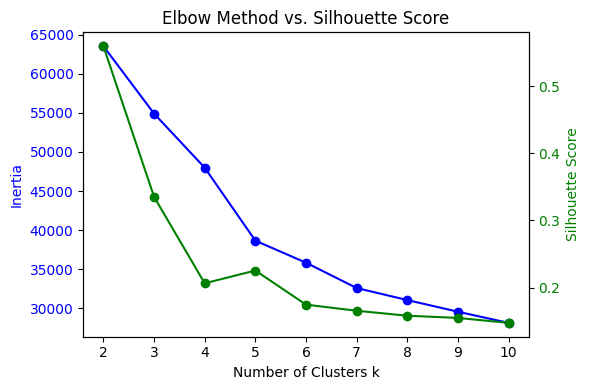

In [21]:
fig, ax1 = plt.subplots(figsize=(6, 4))

# Inertia (Elbow Method)
ax1.plot(k_range, inertias, 'bo-', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters k')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params(axis='y', labelcolor='b')

#Silhouette Score
ax2 = ax1.twinx()
ax2.plot(k_range, sil_scores, 'go-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='g')
ax2.tick_params(axis='y', labelcolor='g')

plt.title('Elbow Method vs. Silhouette Score')
fig.tight_layout()
plt.show()

We identify 5 as the optimum value of k, now re-run K means and record the silhouette score

In [22]:
kmeans_final = KMeans(n_clusters=5, random_state=42, 
                      init='k-means++', n_init='auto')
kmeans_final.fit(scaled_df)
labels_kmeans = kmeans_final.labels_

In [23]:
from sklearn.metrics import silhouette_score
silhouette_score(scaled_df, kmeans_final.labels_, metric='euclidean')

0.22550862542844632

#### Visualizing the results of the K-means
Apart from the silhouette score, another way of interpretting the results of your clustering algorithm is through visualization of the clusters. But, since we are limited to a 2D canvas, we have to do dimensionality reduction first, then cluster the reduced features.

In [24]:
#first reduce the dimensions to 2D with PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_df)

In [25]:
#apply clustering to the PCA result
kmeans_pca = KMeans(n_clusters=5, random_state=0,init='k-means++',n_init="auto").fit(pca_result) 
kmeans_pca.fit(pca_result)
pca_labels_kmeans = kmeans_pca.labels_

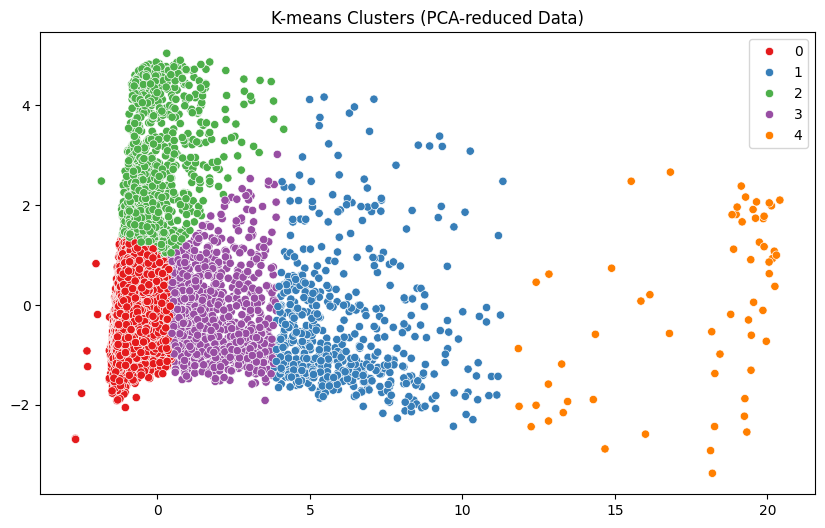

In [26]:
#plot the clusters
plt.figure(figsize=(10, 6)) 
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=pca_labels_kmeans, palette='Set1')
plt.title('K-means Clusters (PCA-reduced Data)')    
plt.show()

#### Gaussian Mixture Methods

Apply GMM, optimize for n_components, compare silhouette scores with Kmeans and then visualize using reduced data.

In [27]:
#apply gaussian mixture model
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=5,covariance_type='full', random_state=42)

# Fit the model
gmm.fit(scaled_df)

# Get cluster labels and probabilities
labels = gmm.predict(scaled_df)
probs = gmm.predict_proba(scaled_df)

In [28]:
#report silhouette score for GMM
silhouette_score(scaled_df, labels, metric='euclidean')

0.03296461234920501

Looks like K-means outperforms GMM, let's optimize for the number of gaussian components and see if that makes a difference.

##### Optimizing for the number of gaussian components

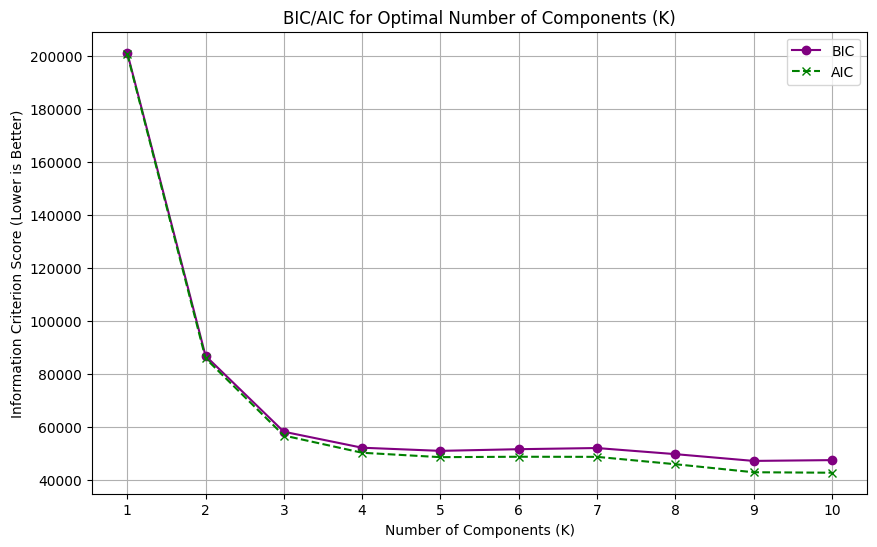

In [ ]:
k_range = range(1, 11)
bic = []
aic = []


for k in k_range:
    gmm = GaussianMixture(n_components=k,covariance_type='full', random_state=42)
    gmm.fit(scaled_df)
    
    bic.append(gmm.bic(scaled_df))
    aic.append(gmm.aic(scaled_df))

# Plot the BIC and AIC scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, bic, marker='o', linestyle='-', color='purple', label='BIC')
plt.plot(k_range, aic, marker='x', linestyle='--', color='green', label='AIC')
plt.title('BIC/AIC for Optimal Number of Components (K)')
plt.xlabel('Number of Components (K)')
plt.ylabel('Information Criterion Score (Lower is Better)')
plt.xticks(k_range)
plt.legend()
plt.grid(True)

plt.show()

In [34]:
gmm_final = GaussianMixture(n_components=3,covariance_type='full', random_state=42)
gmm_final.fit(scaled_df)
labels_gmm = gmm_final.predict(scaled_df)

#report silhouette score for GMM
silhouette_score(scaled_df, labels_gmm, metric='euclidean')

0.19122410398394643

#### Visualizing the Results of GMM

In [39]:
gmm_final = GaussianMixture(n_components=3,covariance_type='full', random_state=42)
gmm_final.fit(pca_result)
labels_gmm = gmm_final.predict(pca_result)



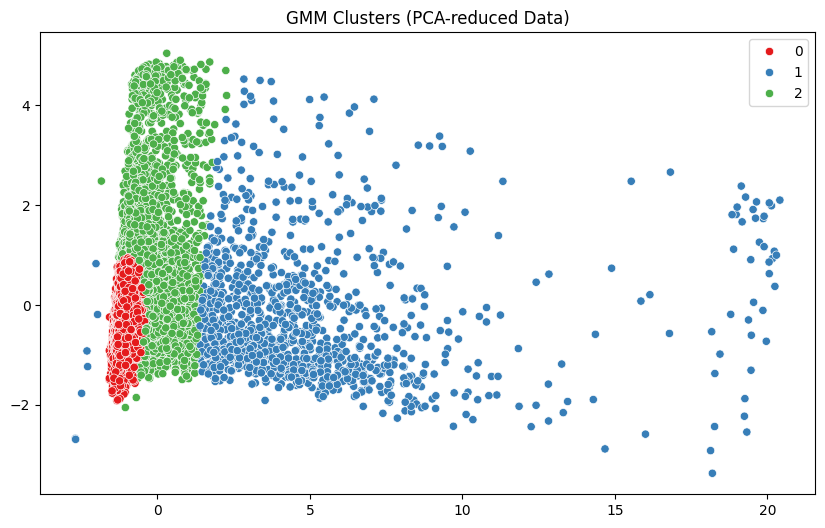

In [40]:
#plot the clusters
plt.figure(figsize=(10, 6)) 
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=labels_gmm, palette='Set1')
plt.title('GMM Clusters (PCA-reduced Data)')    
plt.show()

So far, K-means clustering has done a better job of clustering based on the silhouette scores- K-means has 0.226 at 5 clusters and GMM has 0.191 at 3 clusters. Let's try DBSCAN and see how it performs...

#### DBSCAN

When it comes to DBSCAN, remember from the previous class we learned that there are 2 main parameters, first epsilon which is the radius of our neighbourhood and Minpoints- which is minimum number of points that define a cluster.
So the first step in DBSCAN is choosing the right epsilon- we use what is called a k-distance plot to find the epsilon.

All the k-distance plot does is for every point in your dataset,it find its k nearest neighbors and records the distance to the furthest one, then it sorts all those distances from largest to smallest and plots them.

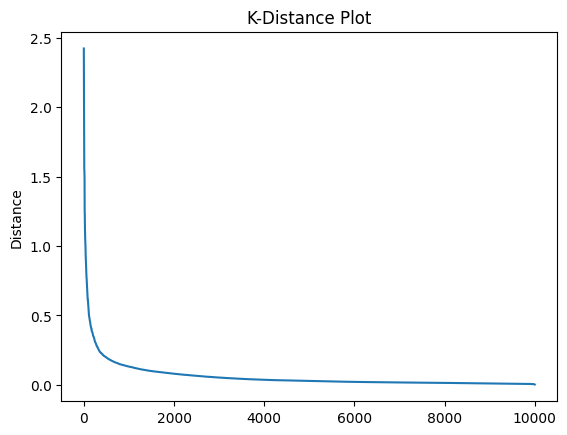

In [46]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

min_samples = max(2 * pca_result.shape[1], 5)
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(pca_result)
distances, _ = nbrs.kneighbors(pca_result)

plt.plot(np.sort(distances[:, -1])[::-1])
plt.title("K-Distance Plot")
plt.ylabel("Distance")
plt.show()

From the k-distance , the best value for epsilo is approx. 0.3...

In [47]:
#apply dbscan clustering
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.3, min_samples=min_samples)
labels_dbscan = dbscan.fit_predict(pca_result)


print(f"\nNoise points (label=-1): {(labels_dbscan == -1).sum()}")
print(f"Number of clusters found: {len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)}")


Noise points (label=-1): 195
Number of clusters found: 11


DBSCAN founds 11 distinct clusters on the reduced data, lets report the silhouette score and see how it performs against the others...

In [48]:
from sklearn.metrics import silhouette_score

# exclude noise points (label = -1)
mask = labels_dbscan != -1
score = silhouette_score(pca_result[mask], labels_dbscan[mask])
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.385


Yaaaay! The silhouette score is better than K-means(0.22) and GMM(0.19)... 

##### Visualizing the DBSCAN clusters

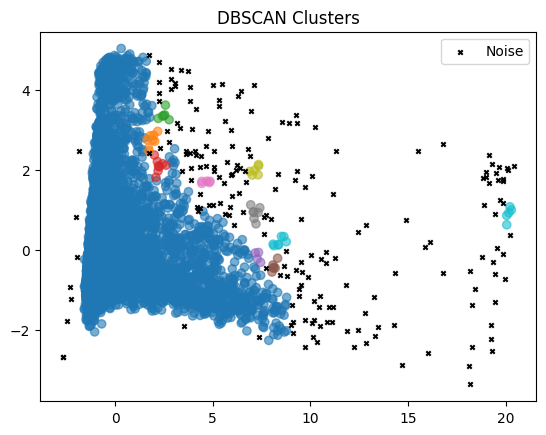

In [52]:
mask = labels_dbscan != -1

plt.scatter(pca_result[mask, 0], pca_result[mask, 1], c=labels_dbscan[mask], cmap='tab10', alpha=0.6)
plt.scatter(pca_result[~mask, 0], pca_result[~mask, 1], c='black', marker='x', s=10, label='Noise')
plt.legend()
plt.title("DBSCAN Clusters")
plt.show()

Interesting, there appears to be a very big cluster and then very small clusters, despite having a higher silhouette score than the rest... from a business perspective this huge cluster is not ver helpful (again, you can totally disagree with me here and just proceed with cluster analysis as is...). The next steps would be to try HDBSCAN and see how that performs and if it is able to differentiate the customers and break apart the huge cluster better...

### Cluster Analysis